In [1]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import plotting
import xml.etree.ElementTree as ET
import meshio
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from pathlib import Path
import importlib.util
import pandas as pd
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.glm.first_level import FirstLevelModel
from nibabel.affines import apply_affine


PROJECT_ROOT = Path("/Volumes/engram/CITRUS/online")
SUBJECT = "sub-01"

# %% Load config and functions
config_path = PROJECT_ROOT / "scratch" / "notebooks" / "citrus_config.py"
functions_path = PROJECT_ROOT / "scratch" / "notebooks" / "citrus_functions.py"

# Load config
spec = importlib.util.spec_from_file_location("citrus_config", config_path)
cfg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

# Load functions
spec_func = importlib.util.spec_from_file_location("citrus_functions", functions_path)
funcs = importlib.util.module_from_spec(spec_func)
spec_func.loader.exec_module(funcs)

# Get subject paths
paths = funcs.get_subject_paths(SUBJECT, cfg)

# Load target coordinate [x, y, z] from kplan roi_centroids.txt (primary ROI in cfg.ROI_DEFS)
coords = funcs.load_target_coords(SUBJECT, cfg)
if coords.size != 3:
    raise ValueError(f"Expected 3 values for target coords, got {coords.size}")

target_xyz = coords.tolist()
print("Target coordinate (x, y, z):", target_xyz)


Target coordinate (x, y, z): [133.0, 152.8, 143.5]


# Part 1: Visualization of T1, pseudoCT, and ROI


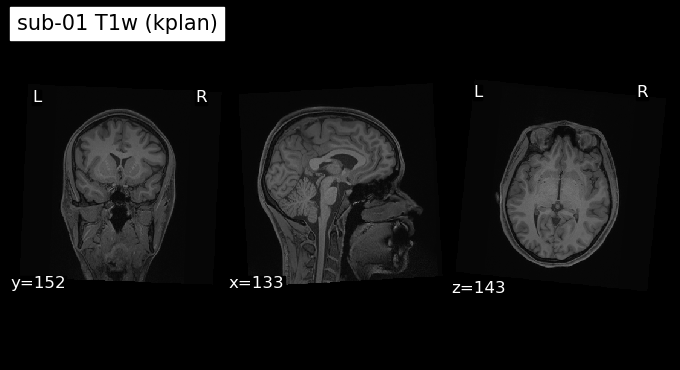

In [2]:
# %% 1) Visualize T1
t1_path = funcs.get_t1_path(SUBJECT, cfg, space='kplan')
t1_img = nib.load(t1_path)
plotting.plot_anat(
    t1_img,
    title=f"{SUBJECT} T1w (kplan)",
    display_mode="ortho",
    annotate=True, colorbar=False, cut_coords=target_xyz, draw_cross=False, black_bg=True,
)
plt.show()


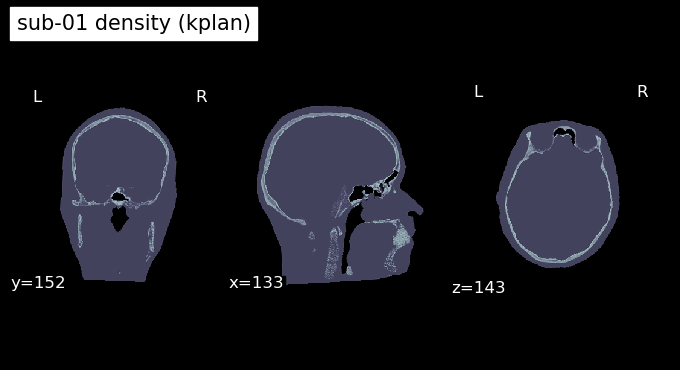

In [3]:
# %% 2) Visualize density
density_path = paths['kplan_input_dir'] / f"{SUBJECT}_density_kplan.nii.gz"
density_img = nib.load(density_path)
plotting.plot_anat(
    density_img,
    title=f"{SUBJECT} density (kplan)",
    display_mode="ortho",
    annotate=True, colorbar=False, cut_coords=target_xyz, draw_cross=False, cmap="bone", black_bg=True,
)
plt.show()


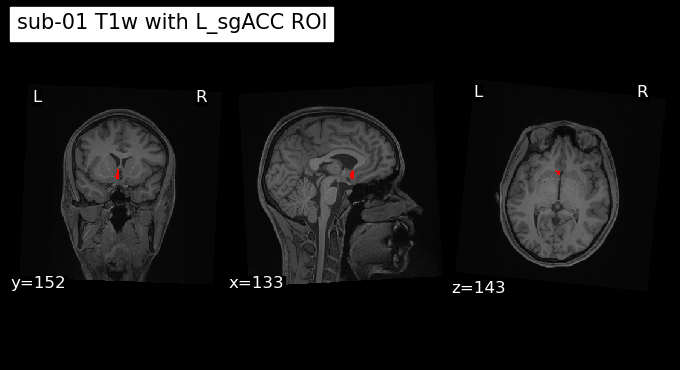

In [4]:
# %% 3) ROI overlaid on T1
# Here we draw the ROI as contours on top of the T1
roi_path = funcs.get_roi_path(SUBJECT, cfg, "sgACC_BA25_L")

roi_img = nib.load(roi_path)
roi_data = roi_img.get_fdata()

# Binarize (threshold > 0)
roi_bin = (roi_data > 0).astype(np.uint8)
roi_bin_img = nib.Nifti1Image(roi_bin, affine=roi_img.affine)

display = plotting.plot_anat(
    t1_img,
    title=f"{SUBJECT} T1w with L_sgACC ROI",
    display_mode="ortho",
    annotate=True, colorbar=False, cut_coords=target_xyz,draw_cross=False,
)

display.add_overlay(roi_bin_img, transparency=1, cmap="autumn")

plt.show()


# Part 2: Transducer Position Visualization


In [5]:
# %% Load transducer positions and SimNIBS mesh
transducer_data = funcs.load_transducer_positions(SUBJECT, cfg, verbose=True)
mesh_data = funcs.load_simnibs_mesh(SUBJECT, cfg, verbose=True)

Loading transducer positions from: sub-01_GUMMarkers20251030.xml
Selected 5 markers:
  Tx-2_L_pos-1
  Tx-2_L_pos-2
  Tx-2_L_pos-3
  Tx-2_L_pos-4
  Tx-2_L_pos-5
Loading SimNIBS mesh from: sub-01.msh

Using scalp tag 1005, n_tris = 92514
Plotting 92514 triangles


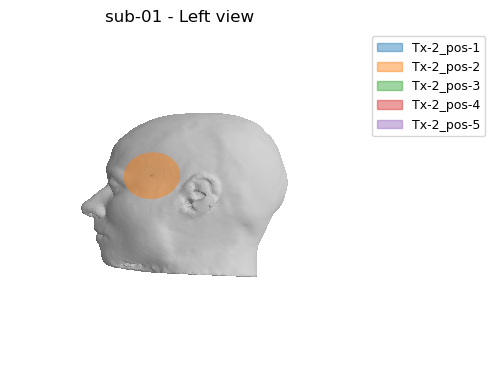

(<Figure size 600x600 with 1 Axes>,
 <Axes3D: title={'center': 'sub-01 - Left view'}>)

In [6]:
# %% Visualize transducer positions - Left view
funcs.plot_transducer_positions(mesh_data, transducer_data, view='left', title=f"{SUBJECT} - Left view")

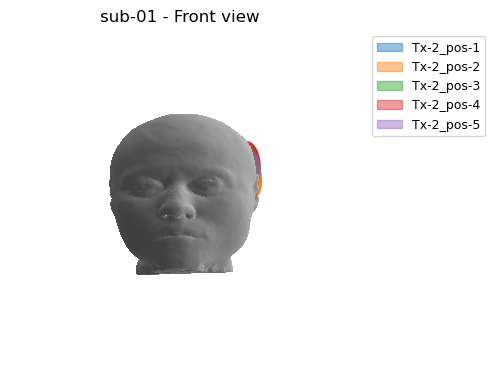

(<Figure size 600x600 with 1 Axes>,
 <Axes3D: title={'center': 'sub-01 - Front view'}>)

In [7]:
# %% Visualize transducer positions - Front view
funcs.plot_transducer_positions(mesh_data, transducer_data, view='front', title=f"{SUBJECT} - Front view")

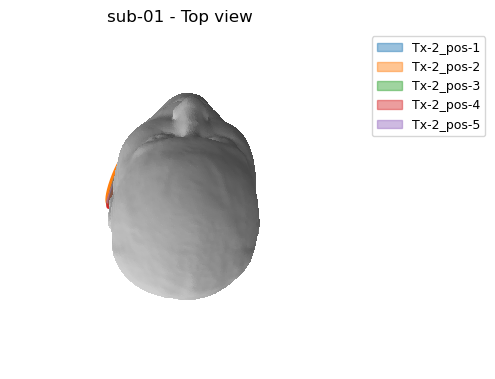

(<Figure size 600x600 with 1 Axes>,
 <Axes3D: title={'center': 'sub-01 - Top view'}>)

In [8]:
# %% Visualize transducer positions - Top view
funcs.plot_transducer_positions(mesh_data, transducer_data, view='top', title=f"{SUBJECT} - Top view")

# Part 3: k-Plan simulation visualization

In [9]:
# %% saved for k-plan visualization code

# Part 4: fMRI GLM Analysis

In [10]:
spec = importlib.util.spec_from_file_location("proj_config", config_path)
cfg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

# Shortcuts
BASE_DIR     = cfg.BASE_DIR
FMRIPREP_DIR = cfg.FMRIPREP_DIR
TEDANA_DIR   = cfg.TEDANA_DIR
ANALYSIS_DIR = cfg.ANALYSIS_DIR
SES_FUNC     = cfg.SESS_FUNC      # "ses-onlineTUS"
TR           = cfg.TR
BLOCK_TRS    = cfg.BLOCK_TRS
BLOCK_DUR    = cfg.BLOCK_DURATION
TUS_OFFSET   = cfg.TUS_ONSET_OFFSET

print("subject:", SUBJECT)
print("BASE_DIR:", BASE_DIR)
print("FMRIPREP_DIR:", FMRIPREP_DIR)
print("TEDANA_DIR:", TEDANA_DIR)
print("ANALYSIS_DIR:", ANALYSIS_DIR)
print("SES_FUNC:", SES_FUNC)
print("TR:", TR, "s")
print("BLOCK_TRS:", BLOCK_TRS, "→ BLOCK_DUR:", BLOCK_DUR, "s")
print("TUS onset offset:", TUS_OFFSET, "s after volume onset")


subject: sub-01
BASE_DIR: /Volumes/engram/CITRUS/online
FMRIPREP_DIR: /Volumes/engram/CITRUS/online/data/derivatives/nordic-tedana/fmriprep
TEDANA_DIR: /Volumes/engram/CITRUS/online/data/derivatives/nordic-tedana/tedana
ANALYSIS_DIR: /Volumes/engram/CITRUS/online/scratch/analysis
SES_FUNC: ses-online
TR: 1.8 s
BLOCK_TRS: 10 → BLOCK_DUR: 18.0 s
TUS onset offset: 1.53 s after volume onset


In [11]:
# %% Prepare & trim tedana-denoised BOLD and fMRIPrep confounds
meta_df = funcs.trim_bold_and_confounds(SUBJECT, cfg, verbose=True)

# %% Generate block-design events for online TUS
funcs.generate_all_block_events(SUBJECT, cfg, verbose=True)


Processing sub-01 task-prot1con acq-onoff
=== sub-01 task-prot1con acq-onoff ===
Total vols: 210
  Option A (drop first+last 5): usable 200, mod10=0
  Option B (drop first 5 only): usable 205, mod10=5
  -> choice: A, trim_start=5, trim_end=205, n_trimmed=200

  Saved trimmed BOLD: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/prep/sub-01_ses-online_task-prot1con_acq-onoff_bold_trim.nii.gz
  Saved trimmed confounds: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/prep/sub-01_ses-online_task-prot1con_acq-onoff_confounds_trim.tsv
  Copied brain mask to: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/prep/sub-01_ses-online_task-prot1con_acq-onoff_brain_mask.nii.gz
Processing sub-01 task-prot1exp acq-onoff
=== sub-01 task-prot1exp acq-onoff ===
Total vols: 210
  Option A (drop first+last 5): usable 200, mod10=0
  Option B (drop first 5 only): usable 205, mod10=5
  -> choice: A, trim_start=5, trim_end=205, n_trimmed=200

  Saved trimmed B


######## GLM (Friston-24, no scrubbing) for sub-01 ########

  Adding run: sub-01 task-prot1con acq-onoff
    Trimmed confounds shape: (200, 132)
    Using 24 motion cols as Friston-24 regressors.

  Adding run: sub-01 task-prot1exp acq-onoff
    Trimmed confounds shape: (200, 141)
    Using 24 motion cols as Friston-24 regressors.

  Adding run: sub-01 task-prot2con acq-offon
    Trimmed confounds shape: (200, 145)
    Using 24 motion cols as Friston-24 regressors.

  Adding run: sub-01 task-prot2exp acq-offon
    Trimmed confounds shape: (200, 142)
    Using 24 motion cols as Friston-24 regressors.

  Adding run: sub-01 task-prot3con acq-offon
    Trimmed confounds shape: (200, 145)
    Using 24 motion cols as Friston-24 regressors.

  Adding run: sub-01 task-prot3exp acq-offon
    Trimmed confounds shape: (200, 148)
    Using 24 motion cols as Friston-24 regressors.

  Adding run: sub-01 task-prot4con acq-onoff
    Trimmed confounds shape: (200, 142)
    Using 24 motion cols as Fri

/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:600: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fm = fm.fit(run_imgs, events=run_events, confounds=run_confounds)



  Design matrix for sub-01 - task-prot1con acq-onoff


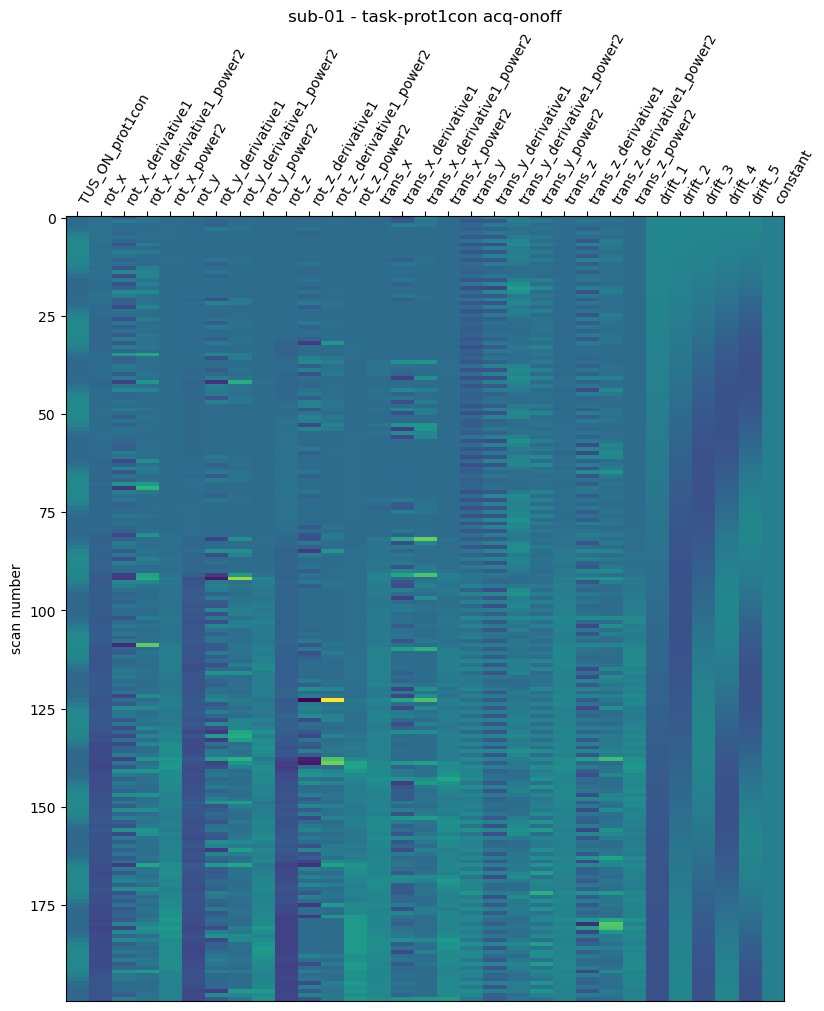


  Design matrix for sub-01 - task-prot1exp acq-onoff


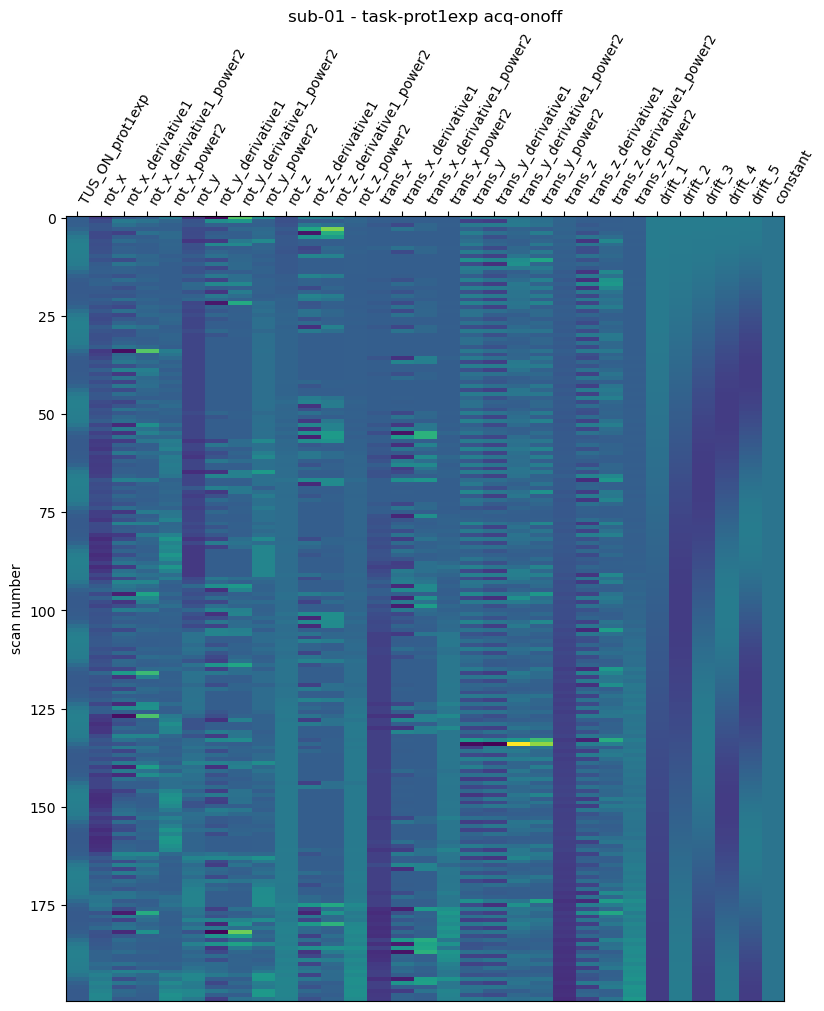


  Design matrix for sub-01 - task-prot2con acq-offon


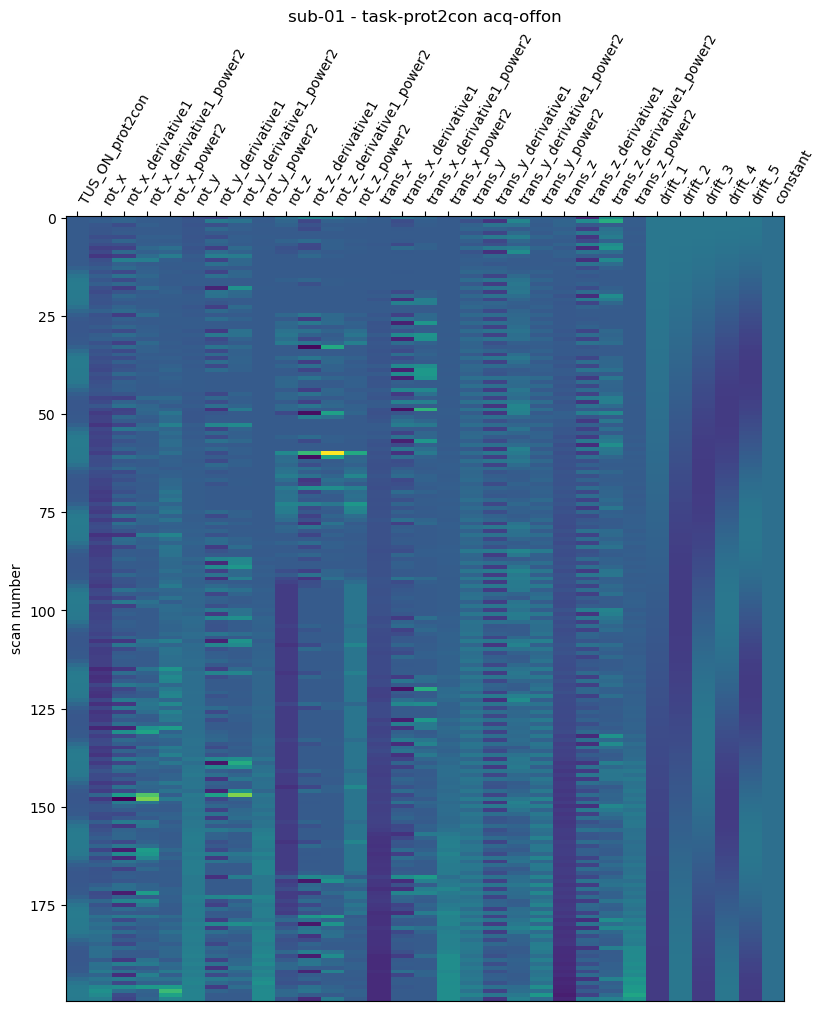


  Design matrix for sub-01 - task-prot2exp acq-offon


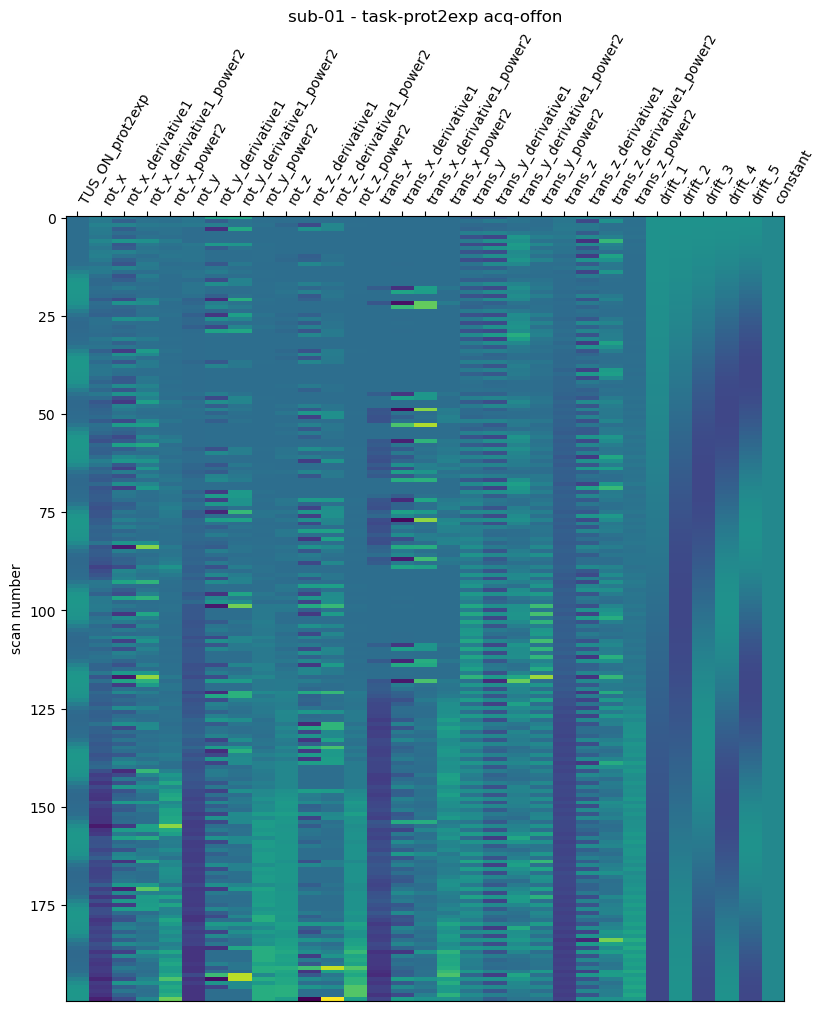


  Design matrix for sub-01 - task-prot3con acq-offon


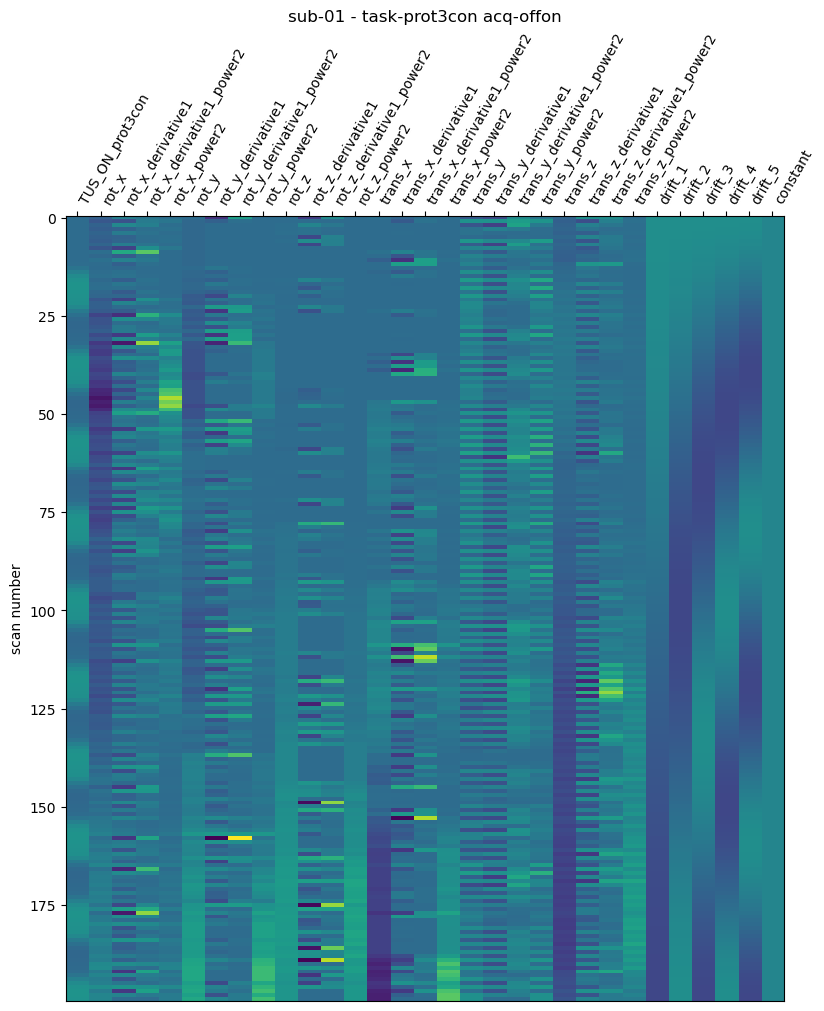


  Design matrix for sub-01 - task-prot3exp acq-offon


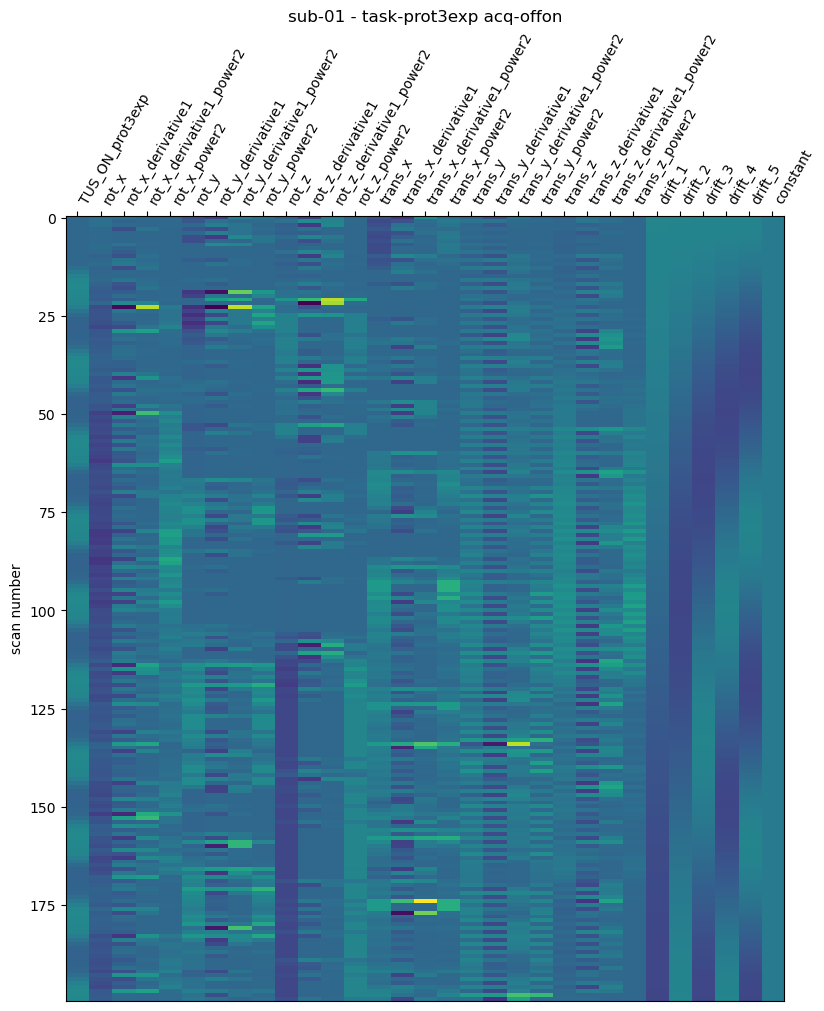


  Design matrix for sub-01 - task-prot4con acq-onoff


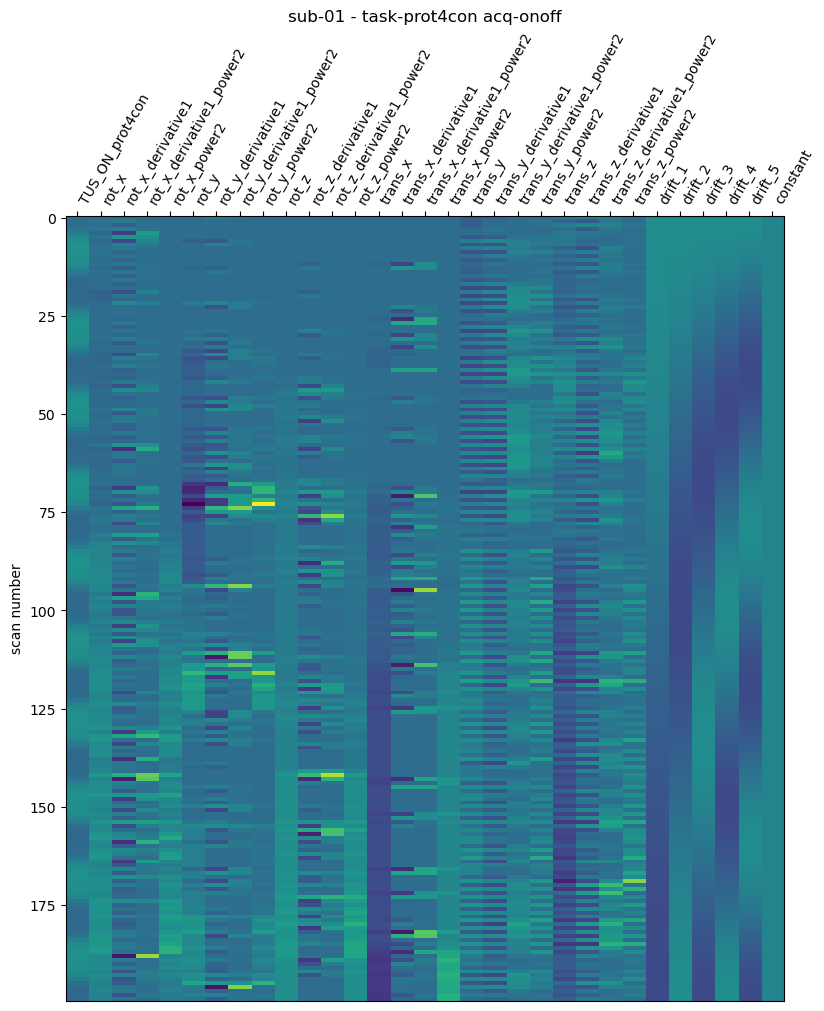


  Design matrix for sub-01 - task-prot4exp acq-onoff


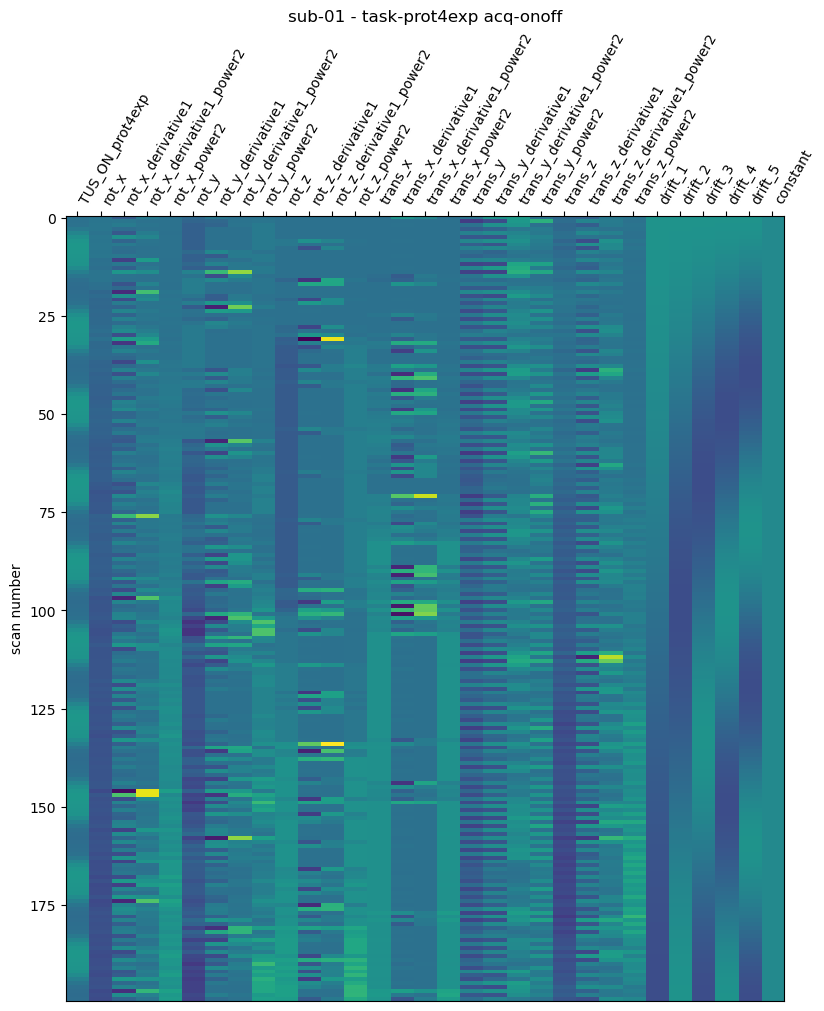

In [12]:
# %% Fit GLM and visualize design matrices (Friston-24, no scrubbing)
first_level_models = {}
design_matrices_by_sub = {}
run_labels_by_sub = {}

print(f"\n######## GLM (Friston-24, no scrubbing) for {SUBJECT} ########")
fm, design_mats, run_labels = funcs.fit_glm(SUBJECT, cfg, verbose=True)

if fm is not None:
    first_level_models[SUBJECT] = fm
    design_matrices_by_sub[SUBJECT] = design_mats
    run_labels_by_sub[SUBJECT] = run_labels
    
    # Visualize design matrices with run names
    funcs.plot_design_matrices(design_mats, run_labels=run_labels, subject=SUBJECT, show=True)

In [13]:
# %% Compute contrasts and save effect / t-stat maps / zmaps
if SUBJECT in first_level_models:
    fm = first_level_models[SUBJECT]
    design_mats = design_matrices_by_sub[SUBJECT]
    funcs.compute_and_save_contrasts(SUBJECT, fm, design_mats, cfg, verbose=True)

  Generated 13 of 13 expected contrasts.
  Computing contrast: exp_gt_con_overall -> {'TUS_ON_prot1exp': 0.25, 'TUS_ON_prot2exp': 0.25, 'TUS_ON_prot3exp': 0.25, 'TUS_ON_prot4exp': 0.25, 'TUS_ON_prot1con': -0.25, 'TUS_ON_prot2con': -0.25, 'TUS_ON_prot3con': -0.25, 'TUS_ON_prot4con': -0.25}
    Saved effect image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-exp_gt_con_overall_effect.nii.gz
    Saved t-stat image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-exp_gt_con_overall_tstat.nii.gz
    Saved z-score image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-exp_gt_con_overall_zmap.nii.gz
  Computing contrast: prot1_con_gt_baseline -> {'TUS_ON_prot1con': 1.0}
    Saved effect image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_con_gt_baseline_effect.nii.gz


/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:885: UserWarning: Contrast for run 1 is null.
  eff_img = fm.compute_contrast(weights_per_run, output_type="effect_size")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:885: UserWarning: Contrast for run 2 is null.
  eff_img = fm.compute_contrast(weights_per_run, output_type="effect_size")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:885: UserWarning: Contrast for run 3 is null.
  eff_img = fm.compute_contrast(weights_per_run, output_type="effect_size")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:885: UserWarning: Contrast for run 4 is null.
  eff_img = fm.compute_contrast(weights_per_run, output_type="effect_size")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:885: UserWarning: Contrast for run 5 is null.
  eff_img = fm.compute_contrast(weights_per_run, output_type="effect_size")
/Volumes/engram/CITRUS/online/scratch/notebooks/ci

    Saved t-stat image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_con_gt_baseline_tstat.nii.gz
    Saved z-score image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_con_gt_baseline_zmap.nii.gz
  Computing contrast: prot1_exp_gt_baseline -> {'TUS_ON_prot1exp': 1.0}


/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:897: UserWarning: Contrast for run 1 is null.
  z_img = fm.compute_contrast(weights_per_run, output_type="z_score")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:897: UserWarning: Contrast for run 2 is null.
  z_img = fm.compute_contrast(weights_per_run, output_type="z_score")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:897: UserWarning: Contrast for run 3 is null.
  z_img = fm.compute_contrast(weights_per_run, output_type="z_score")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:897: UserWarning: Contrast for run 4 is null.
  z_img = fm.compute_contrast(weights_per_run, output_type="z_score")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:897: UserWarning: Contrast for run 5 is null.
  z_img = fm.compute_contrast(weights_per_run, output_type="z_score")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:897: UserWar

    Saved effect image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_exp_gt_baseline_effect.nii.gz
    Saved t-stat image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_exp_gt_baseline_tstat.nii.gz


/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:891: UserWarning: Contrast for run 0 is null.
  t_img = fm.compute_contrast(weights_per_run, output_type="stat")
/Volumes/engram/CITRUS/online/scratch/notebooks/citrus_functions.py:897: UserWarning: Contrast for run 0 is null.
  z_img = fm.compute_contrast(weights_per_run, output_type="z_score")


    Saved z-score image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_exp_gt_baseline_zmap.nii.gz
  Computing contrast: prot1_exp_gt_con -> {'TUS_ON_prot1exp': 1.0, 'TUS_ON_prot1con': -1.0}
    Saved effect image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_exp_gt_con_effect.nii.gz
    Saved t-stat image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_exp_gt_con_tstat.nii.gz
    Saved z-score image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot1_exp_gt_con_zmap.nii.gz
  Computing contrast: prot2_con_gt_baseline -> {'TUS_ON_prot2con': 1.0}
    Saved effect image: /Volumes/engram/CITRUS/online/scratch/analysis/sub-01/ses-online/glm/sub-01_ses-online_contrast-prot2_con_gt_baseline_effect.nii.gz
    Saved t-stat image: /Volumes/engram/CITRUS/online/scratch/analysis/sub

In [14]:
# %% Visualize first-level zmap on subject T1w
# List available contrasts
available_contrasts = funcs.list_available_contrasts(SUBJECT, cfg, map_type='zmap')
print(f"\nAvailable zmap contrasts for {SUBJECT}:")
for i, cname in enumerate(available_contrasts, 1):
    print(f"  {i}. {cname}")



Available zmap contrasts for sub-01:
  1. exp_gt_con_overall
  2. prot1_con_gt_baseline
  3. prot1_exp_gt_baseline
  4. prot1_exp_gt_con
  5. prot2_con_gt_baseline
  6. prot2_exp_gt_baseline
  7. prot2_exp_gt_con
  8. prot3_con_gt_baseline
  9. prot3_exp_gt_baseline
  10. prot3_exp_gt_con
  11. prot4_con_gt_baseline
  12. prot4_exp_gt_baseline
  13. prot4_exp_gt_con



Plotting 1 contrasts: ['exp_gt_con_overall']

  Processing contrast: exp_gt_con_overall
    Saved warped map → sub-01_ses-online_contrast-exp_gt_con_overall_space-T1w_zmap.nii.gz
    Visualizing exp_gt_con_overall (zmap) ...


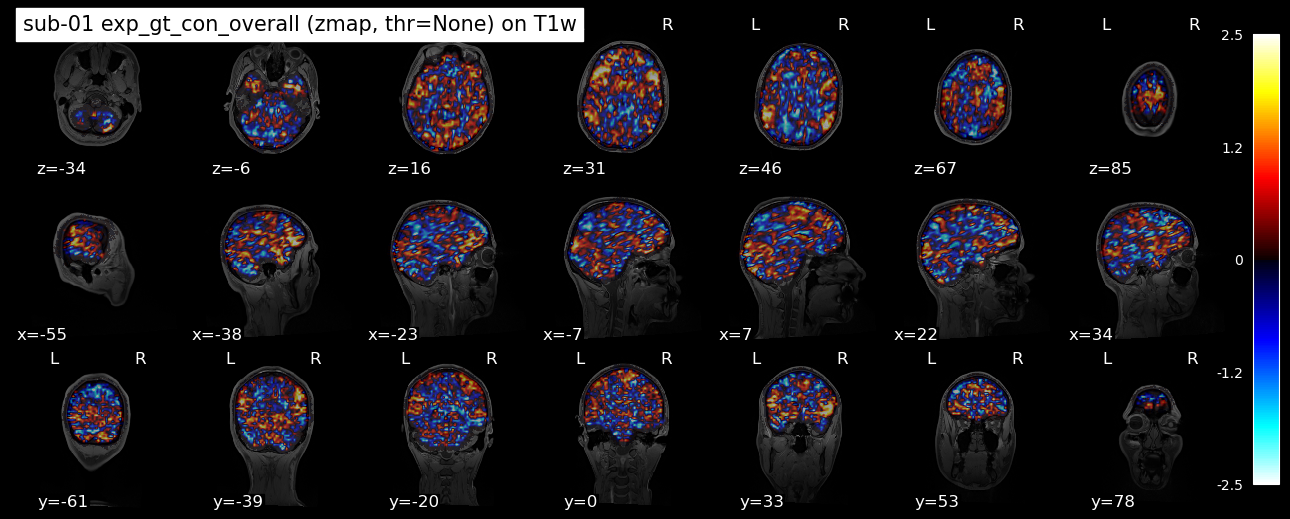

    Saved warped map → sub-01_ses-online_contrast-exp_gt_con_overall_space-T1w_zmap.nii.gz
    Visualizing exp_gt_con_overall (zmap) ...


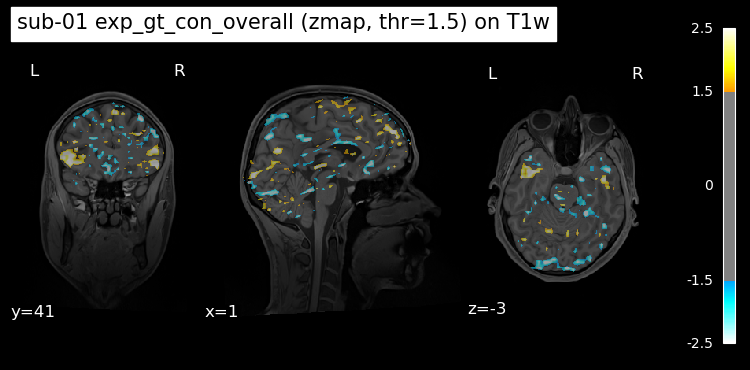

In [15]:

# Define which contrasts to plot
plot_contrasts = {
    "exp_gt_con_overall", 
}

print(f"\nPlotting {len(plot_contrasts)} contrasts: {sorted(plot_contrasts)}")

for cname in sorted(plot_contrasts):
    if cname not in available_contrasts:
        print(f"\n  Skipping contrast (not found): {cname}")
        continue
    
    print(f"\n  Processing contrast: {cname}")
    
    # Mosaic view with 7 cuts
    funcs.plot_contrast_on_t1w(
        SUBJECT, cname, cfg, map_type='zmap',
        display_mode='mosaic', cut_coords=7,
        verbose=True, show=True
    )
    
    # Ortho view with target coordinates (uncomment to use)
    funcs.plot_contrast_on_t1w(
        SUBJECT, cname, cfg, map_type='zmap',
        display_mode='ortho', threshold=1.5, cut_coords=[1,41,-3],
        verbose=True, show=True
    )
    

## sgACC - Within-Hemisphere Connectivity Analysis

Functional connectivity analysis between sgACC ROIs and Yeo 7 network parcellation, comparing exp vs con conditions across protocols.


In [16]:
# %% Connectivity analysis: sgACC - Yeo 7 networks
from nilearn.datasets import fetch_atlas_yeo_2011
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker
from nilearn.image import resample_to_img, load_img
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns

SES_FUNC = cfg.SESS_FUNC

# Set up output directory
connectivity_dir = paths['prep_dir'].parent / 'connectivity'
connectivity_dir.mkdir(exist_ok=True)

print("="*80)
print("sgACC - Within-Hemisphere Connectivity Analysis")
print("="*80)

# Load Yeo 7 network parcellation
print("\n1. Loading Yeo 7 network parcellation...")
yeo_atlas = fetch_atlas_yeo_2011()
yeo_7networks = yeo_atlas.thick_7
print(f"   Yeo 7 networks atlas: {yeo_7networks}")

# Load Yeo atlas to get network labels
yeo_img = load_img(yeo_7networks)
yeo_data = yeo_img.get_fdata()
network_labels = {
    1: 'Visual',
    2: 'Somatomotor',
    3: 'Dorsal Attention',
    4: 'Ventral Attention',
    5: 'Limbic',
    6: 'Frontoparietal',
    7: 'Default'
}
print(f"   Network labels: {network_labels}")

# Get reference functional image (boldref space) for warping
func_dir = paths['func_dir']
boldref_files = list(func_dir.glob(f"{SUBJECT}_{SES_FUNC}_task-*_*_space-boldref_desc-preproc_bold.nii.gz"))
if not boldref_files:
    # Try alternative naming
    boldref_files = list(func_dir.glob(f"{SUBJECT}_{SES_FUNC}_task-*_*_boldref.nii.gz"))

if boldref_files:
    reference_img = load_img(str(boldref_files[0]))
    print(f"\n2. Reference functional image: {boldref_files[0].name}")
else:
    # Use first trimmed BOLD as reference
    prep_dir = paths['prep_dir']
    bold_trim_files = sorted(prep_dir.glob(f"{SUBJECT}_{SES_FUNC}_task-*_*_bold_trim.nii.gz"))
    if bold_trim_files:
        reference_img = load_img(str(bold_trim_files[0]))
        print(f"\n2. Reference functional image: {bold_trim_files[0].name}")
    else:
        raise FileNotFoundError("Could not find reference functional image")

# Warp Yeo atlas to functional space
print("\n3. Warping Yeo atlas to functional space...")
yeo_func = resample_to_img(yeo_img, reference_img, interpolation='nearest')
yeo_func_path = connectivity_dir / f"{SUBJECT}_Yeo7networks_space-boldref.nii.gz"
nib.save(yeo_func, yeo_func_path)
print(f"   Saved: {yeo_func_path.name}")

# Load sgACC ROIs in functional space
# First, check if ROIs exist in functional space, otherwise we'll need to warp them
print("\n4. Loading sgACC ROIs...")
roi_names = ['sgACC_BA25_L', 'sgACC_BA25_R']
roi_images = {}

for roi_name in roi_names:
    # Check if ROI exists in functional/boldref space
    roi_func_path = paths['prep_dir'].parent / 'roi' / f"{SUBJECT}_{SES_FUNC}_{roi_name}_space-boldref.nii.gz"
    
    if roi_func_path.exists():
        roi_images[roi_name] = load_img(str(roi_func_path))
        print(f"   {roi_name}: Found in functional space")
    else:
        # Try to load from template and warp (would need transforms)
        print(f"   {roi_name}: Not found in functional space - will need to warp from template")
        # For now, we'll skip if not available
        roi_template_path = cfg.ROI_TEMPLATE_DIR / next(
            (rd['template_fname'] for rd in cfg.ROI_DEFS if rd['roi_name'] == roi_name), None
        )
        if roi_template_path and roi_template_path.exists():
            roi_template = load_img(str(roi_template_path))
            # Warp to functional space (simplified - in practice would use proper transforms)
            roi_func = resample_to_img(roi_template, reference_img, interpolation='nearest')
            roi_func_dir = roi_func_path.parent
            roi_func_dir.mkdir(parents=True, exist_ok=True)
            nib.save(roi_func, roi_func_path)
            roi_images[roi_name] = roi_func
            print(f"   {roi_name}: Warped and saved to functional space")

print(f"\n   Loaded {len(roi_images)} ROIs")


sgACC - Within-Hemisphere Connectivity Analysis

1. Loading Yeo 7 network parcellation...


/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5077/2579657168.py:21: DeprecationWarning: From release >=0.13.0, instead of returning several atlas image accessible via different keys, this fetcher will return the atlas as a dictionary with a single atlas image, accessible through a 'maps' key. To suppress this warning, Please use the parameters 'n_networks' and 'thickness' to specify the exact atlas image you want.
  yeo_atlas = fetch_atlas_yeo_2011()


[fetch_atlas_yeo_2011] Dataset found in /Users/suhas/nilearn_data/yeo_2011

   Yeo 7 networks atlas: /Users/suhas/nilearn_data/yeo_2011/Yeo_JNeurophysiol11_MNI152/Yeo2011_7Networks_MNI152_FreeSurferConformed1mm_LiberalMask.nii.gz
   Network labels: {1: 'Visual', 2: 'Somatomotor', 3: 'Dorsal Attention', 4: 'Ventral Attention', 5: 'Limbic', 6: 'Frontoparietal', 7: 'Default'}

2. Reference functional image: sub-01_ses-online_task-prot1exp_acq-onoff_desc-hmc_boldref.nii.gz

3. Warping Yeo atlas to functional space...
   Saved: sub-01_Yeo7networks_space-boldref.nii.gz

4. Loading sgACC ROIs...
   sgACC_BA25_L: Found in functional space
   sgACC_BA25_R: Found in functional space

   Loaded 2 ROIs


/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5077/2579657168.py:61: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  yeo_func = resample_to_img(yeo_img, reference_img, interpolation='nearest')
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5077/2579657168.py:61: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  yeo_func = resample_to_img(yeo_img, reference_img, interpolation='nearest')


In [17]:
# %% Extract time series and calculate connectivity
print("\n5. Extracting time series and calculating connectivity...")

# Get all trimmed BOLD files
prep_dir = paths['prep_dir']
bold_trim_files = sorted(prep_dir.glob(f"{SUBJECT}_{SES_FUNC}_task-*_*_bold_trim.nii.gz"))

if not bold_trim_files:
    raise FileNotFoundError(f"No trimmed BOLD files found in {prep_dir}")

print(f"   Found {len(bold_trim_files)} runs")

# Create maskers for sgACC ROIs
roi_maskers = {}
for roi_name, roi_img in roi_images.items():
    roi_maskers[roi_name] = NiftiMasker(mask_img=roi_img, standardize=True, 
                                       memory='nilearn_cache', verbose=0)

# Extract time series and calculate connectivity
connectivity_results = []

for bold_file in bold_trim_files:
    # Parse task and condition
    task, acq = cfg.parse_task_and_acq(bold_file)
    prot, condition = cfg.task_to_protocol_and_condition(task)
    
    print(f"\n   Processing: {task} ({prot}, {condition})")
    
    # Load BOLD data
    bold_img = load_img(str(bold_file))
    
    # Extract time series from sgACC ROIs
    roi_ts = {}
    for roi_name, masker in roi_maskers.items():
        ts = masker.fit_transform(bold_img)
        roi_ts[roi_name] = ts.mean(axis=1) if ts.ndim > 1 else ts  # Average across voxels
    
    # For each ROI, extract connectivity with networks in the same hemisphere
    for roi_name, seed_ts in roi_ts.items():
        hemisphere = 'left' if roi_name.startswith('L_') else 'right'
        
        # Create hemisphere-specific Yeo mask
        yeo_data = yeo_func.get_fdata()
        mid_x = yeo_data.shape[0] // 2
        
        if hemisphere == 'left':
            # Left hemisphere: x < mid_x
            hemisphere_mask = np.zeros_like(yeo_data, dtype=bool)
            for x in range(mid_x):
                hemisphere_mask[x, :, :] = True
        else:
            # Right hemisphere: x >= mid_x
            hemisphere_mask = np.zeros_like(yeo_data, dtype=bool)
            for x in range(mid_x, yeo_data.shape[0]):
                hemisphere_mask[x, :, :] = True
        
        # Calculate connectivity with each network in the same hemisphere
        for network_id, network_name in network_labels.items():
            # Create mask for this network in this hemisphere
            network_mask = (yeo_data == network_id) & hemisphere_mask
            
            if not np.any(network_mask):
                continue
            
            # Extract time series from this network
            network_mask_img = nib.Nifti1Image(network_mask.astype(float), yeo_func.affine)
            network_masker = NiftiMasker(mask_img=network_mask_img, standardize=True, 
                                        memory='nilearn_cache', verbose=0)
            network_ts = network_masker.fit_transform(bold_img)
            network_ts_mean = network_ts.mean(axis=1) if network_ts.ndim > 1 else network_ts
            
            # Calculate Pearson correlation
            if len(seed_ts) == len(network_ts_mean) and len(seed_ts) > 10:
                r, p = pearsonr(seed_ts, network_ts_mean)
                
                connectivity_results.append({
                    'subject': SUBJECT,
                    'protocol': prot,
                    'condition': condition,
                    'roi_name': roi_name,
                    'hemisphere': hemisphere,
                    'network_id': network_id,
                    'network_name': network_name,
                    'connectivity_r': r,
                    'connectivity_p': p,
                    'n_timepoints': len(seed_ts)
                })

# Convert to DataFrame
connectivity_df = pd.DataFrame(connectivity_results)
print(f"\n   Calculated {len(connectivity_df)} connectivity values")

# Save results
connectivity_csv = connectivity_dir / f"{SUBJECT}_sgACC_Yeo7_connectivity.csv"
connectivity_df.to_csv(connectivity_csv, index=False)
print(f"   Saved: {connectivity_csv.name}")




5. Extracting time series and calculating connectivity...
   Found 8 runs

   Processing: prot1con (prot1, con)

   Processing: prot1exp (prot1, exp)

   Processing: prot2con (prot2, con)

   Processing: prot2exp (prot2, exp)

   Processing: prot3con (prot3, con)

   Processing: prot3exp (prot3, exp)

   Processing: prot4con (prot4, con)

   Processing: prot4exp (prot4, exp)

   Calculated 112 connectivity values
   Saved: sub-01_sgACC_Yeo7_connectivity.csv



8. Creating spider/radar plots...
   Saved spider plot: sub-01_sgACC_Yeo7_spider_prot1.png


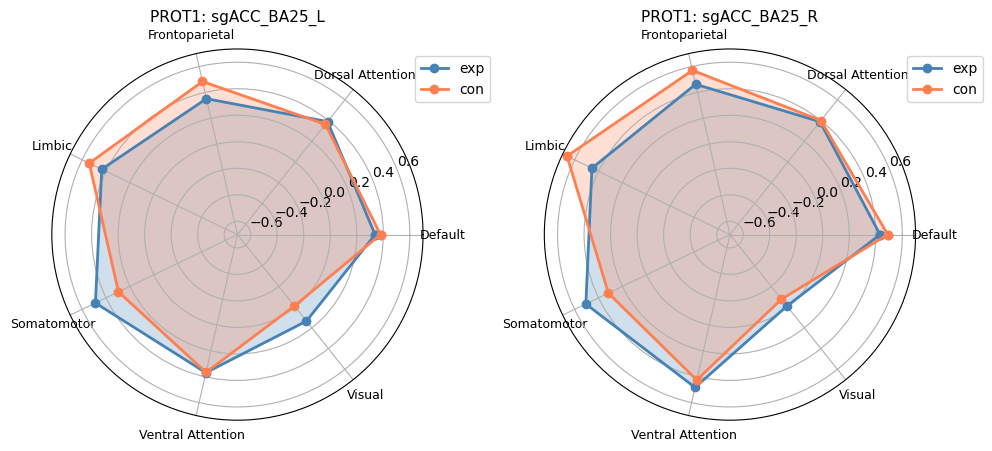

   Saved spider plot: sub-01_sgACC_Yeo7_spider_prot2.png


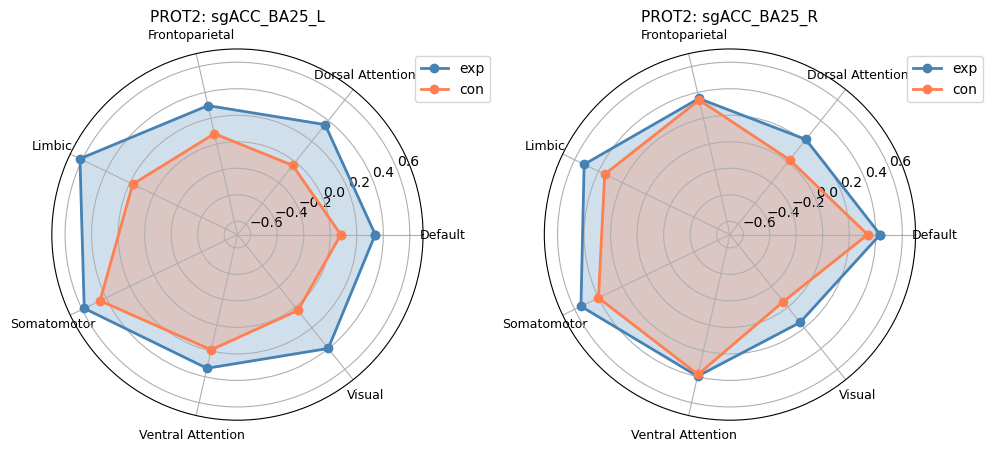

   Saved spider plot: sub-01_sgACC_Yeo7_spider_prot3.png


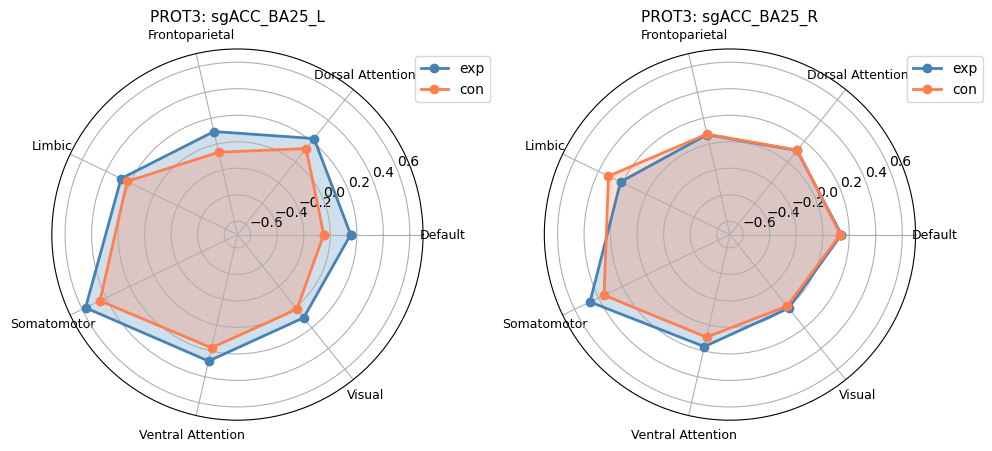

   Saved spider plot: sub-01_sgACC_Yeo7_spider_prot4.png


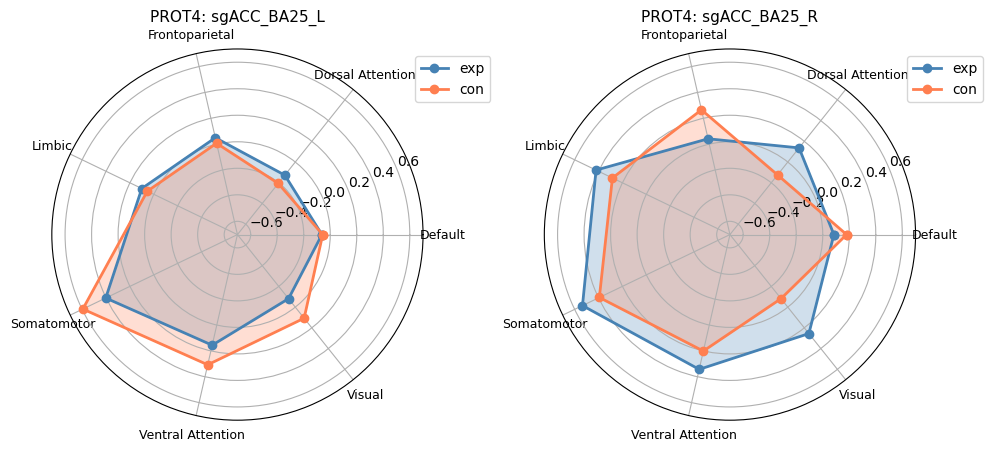


Connectivity analysis complete!


In [18]:
# %% Alternative visualization: Spider/radar plots for each ROI
print("\n8. Creating spider/radar plots...")

from math import pi

def create_spider_plot(ax, data_exp, data_con, networks, title, colors=['steelblue', 'coral']):
    """Create a spider/radar plot for connectivity data."""
    # Number of variables (networks)
    N = len(networks)
    
    # Compute angle for each network
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Prepare data
    values_exp = [data_exp.get(net, 0) for net in networks]
    values_exp += values_exp[:1]  # Complete the circle
    
    values_con = [data_con.get(net, 0) for net in networks]
    values_con += values_con[:1]  # Complete the circle
    
    # Plot
    ax.plot(angles, values_exp, 'o-', linewidth=2, label='exp', color=colors[0])
    ax.fill(angles, values_exp, alpha=0.25, color=colors[0])
    ax.plot(angles, values_con, 'o-', linewidth=2, label='con', color=colors[1])
    ax.fill(angles, values_con, alpha=0.25, color=colors[1])
    
    # Add network labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(networks, fontsize=9)
    ax.set_ylim([-0.7, 0.7])  # Typical connectivity range
    ax.set_title(title, fontsize=11, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
    ax.grid(True)

if not connectivity_df.empty:
    protocols = sorted(connectivity_df['protocol'].unique())
    #roi_names_plot = ['L_sgACC_anat', 'R_sgACC_anat', 'L_sgACC_sphere', 'R_sgACC_sphere']
    roi_names_plot = ['sgACC_BA25_L', 'sgACC_BA25_R']
    roi_names_plot = [r for r in roi_names_plot if r in connectivity_df['roi_name'].unique()]
    networks = sorted(connectivity_df['network_name'].unique())
    
    # Create spider plots for each protocol and ROI
    for prot in protocols:
        prot_data = connectivity_df[connectivity_df['protocol'] == prot]
        
        n_rois = len(roi_names_plot)
        fig, axes = plt.subplots(1, n_rois, figsize=(5*n_rois, 5), subplot_kw=dict(projection='polar'))
        if n_rois == 1:
            axes = [axes]
        
        for idx, roi_name in enumerate(roi_names_plot):
            roi_data = prot_data[prot_data['roi_name'] == roi_name]
            
            # Get exp and con connectivity values
            data_exp = {}
            data_con = {}
            
            for network_name in networks:
                network_data = roi_data[roi_data['network_name'] == network_name]
                exp_data = network_data[network_data['condition'] == 'exp']
                con_data = network_data[network_data['condition'] == 'con']
                
                if not exp_data.empty:
                    data_exp[network_name] = exp_data['connectivity_r'].iloc[0]
                if not con_data.empty:
                    data_con[network_name] = con_data['connectivity_r'].iloc[0]
            
            # Create spider plot
            create_spider_plot(axes[idx], data_exp, data_con, networks, 
                             f'{prot.upper()}: {roi_name}')
        
        plt.tight_layout()
        
        # Save figure
        fig_path = connectivity_dir / f"{SUBJECT}_sgACC_Yeo7_spider_{prot}.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"   Saved spider plot: {fig_path.name}")
        plt.show()

print("\n" + "="*80)
print("Connectivity analysis complete!")
print("="*80)


# TODO:
[] check sgACC-network results - exp vs con conditions - spider plots?
[] 